In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

# Load CSV
df_path = "/ghome/group02/Marina/mcv-c6-2026-team2/Week2/results/grid_search/kalman_filter/summary.csv"
df = pd.read_csv(df_path)


In [2]:
df.head()

,iou,max_age,conf_threshold,filter_thr,min_hits,HOTA,IDF1
0,0.2,0,0.3,0.3,0,65.074,61.450
1,0.2,0,0.3,0.3,1,65.040,61.553
2,0.2,0,0.3,0.3,3,64.746,61.392
3,0.2,0,0.3,0.3,5,64.410,61.144
4,0.2,0,0.3,0.3,10,63.651,60.420


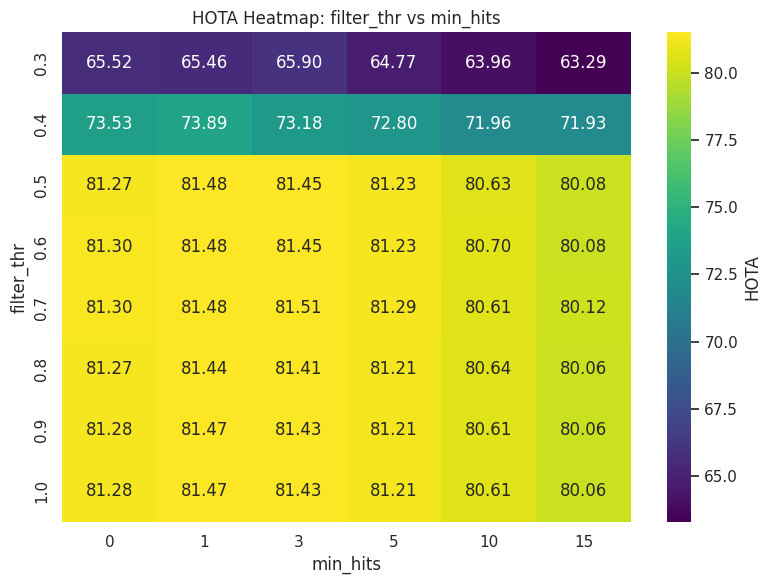

In [3]:

# Choose metric to visualize
metric = "HOTA"   # or "IDF1"

# Create pivot table
heatmap_data = df.pivot_table(
    values=metric,
    index="filter_thr",
    columns="min_hits",
    aggfunc="mean"
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": metric},
)

plt.title(f"{metric} Heatmap: filter_thr vs min_hits")
plt.xlabel("min_hits")
plt.ylabel("filter_thr")

plt.tight_layout()
plt.show()

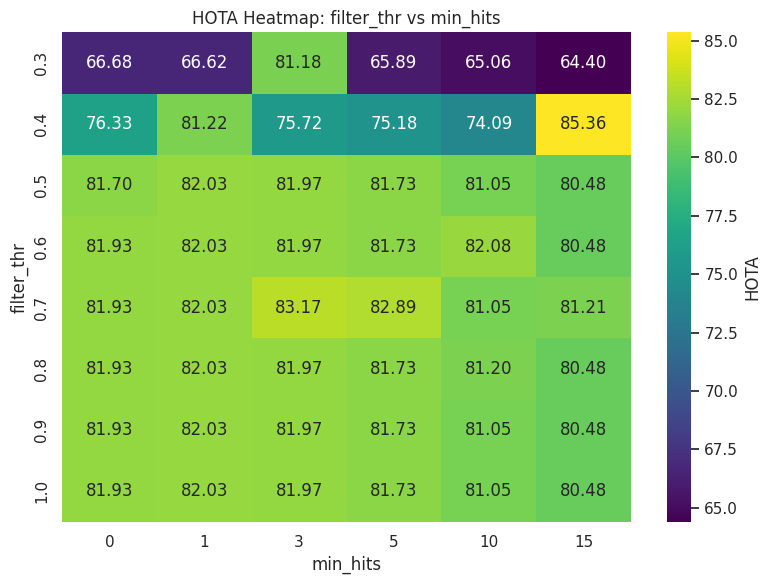

In [4]:

# Choose metric to visualize
metric = "HOTA"   # or "IDF1"

# Create pivot table
heatmap_data = df.pivot_table(
    values=metric,
    index="filter_thr",
    columns="min_hits",
    aggfunc="max"
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": metric},
)

plt.title(f"{metric} Heatmap: filter_thr vs min_hits")
plt.xlabel("min_hits")
plt.ylabel("filter_thr")

plt.tight_layout()
plt.show()

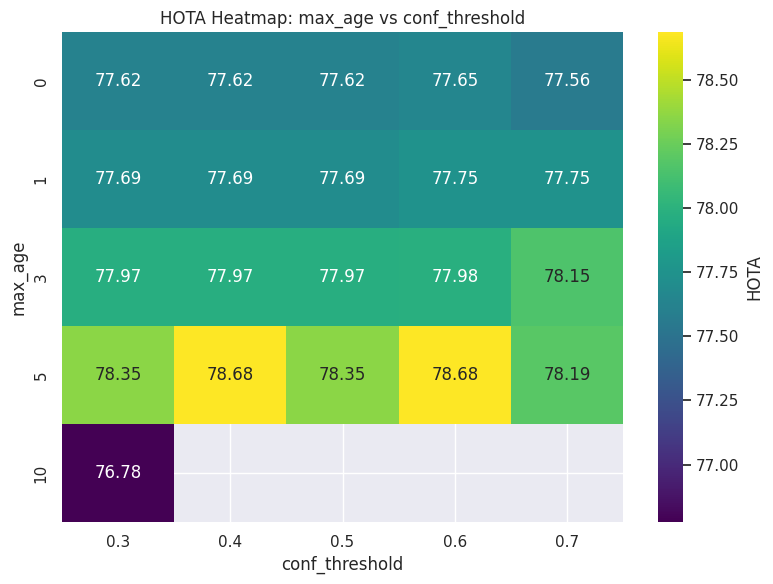

In [5]:

# Choose metric to visualize
metric = "HOTA"   # or "IDF1"

# Create pivot table
heatmap_data = df.pivot_table(
    values=metric,
    index="max_age",
    columns="conf_threshold",
    aggfunc="mean"
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": metric},
)

plt.title(f"{metric} Heatmap: max_age vs conf_threshold")
plt.xlabel("conf_threshold")
plt.ylabel("max_age")

plt.tight_layout()
plt.show()

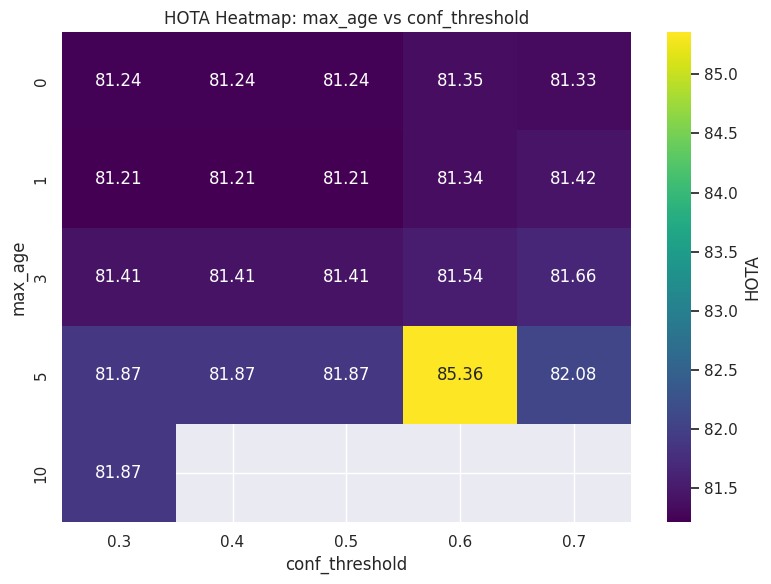

In [6]:

# Choose metric to visualize
metric = "HOTA"   # or "IDF1"

# Create pivot table
heatmap_data = df.pivot_table(
    values=metric,
    index="max_age",
    columns="conf_threshold",
    aggfunc="max"
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": metric},
)

plt.title(f"{metric} Heatmap: max_age vs conf_threshold")
plt.xlabel("conf_threshold")
plt.ylabel("max_age")

plt.tight_layout()
plt.show()

In [7]:
# Load CSV
df2_1 = pd.read_csv("/ghome/group02/Marina/mcv-c6-2026-team2/Week2/results/grid_search_2/kalman_filter/summary.csv")
df2_2 = pd.read_csv("/ghome/group02/Marina/mcv-c6-2026-team2/Week2/results/grid_search_3/kalman_filter/summary.csv")
df2 = pd.concat([df2_1, df2_2], ignore_index=True)
df2.head()

,iou,max_age,conf_threshold,filter_thr,min_hits,HOTA,IDF1
0,0.2,0,0.5,0.5,3,81.216,77.797
1,0.2,0,0.6,0.5,3,81.260,77.886
2,0.2,0,0.7,0.5,3,81.157,77.789
3,0.2,0,0.8,0.5,3,81.188,77.903
4,0.2,0,0.9,0.5,3,81.099,77.849


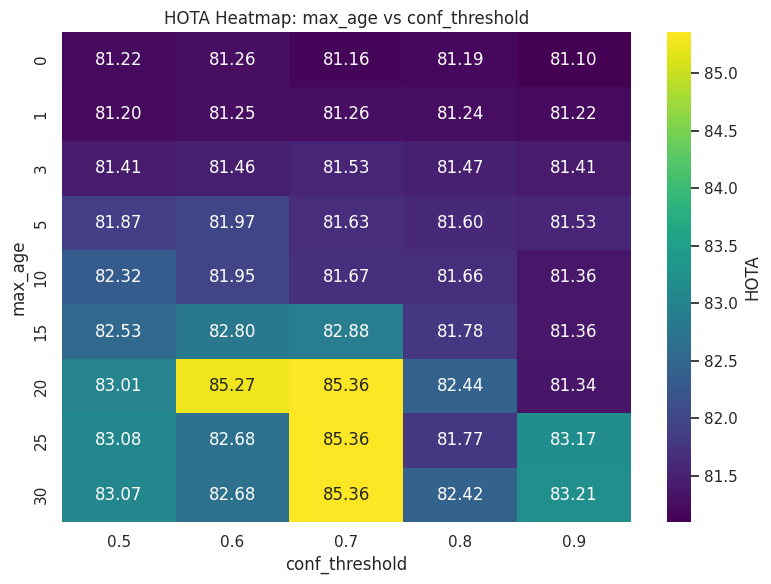

In [8]:

# Choose metric to visualize
metric = "HOTA"   # or "IDF1"

# Create pivot table
heatmap_data = df2.pivot_table(
    values=metric,
    index="max_age",
    columns="conf_threshold",
    aggfunc="max"
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": metric},
)

plt.title(f"{metric} Heatmap: max_age vs conf_threshold")
plt.xlabel("conf_threshold")
plt.ylabel("max_age")

plt.tight_layout()
plt.show()

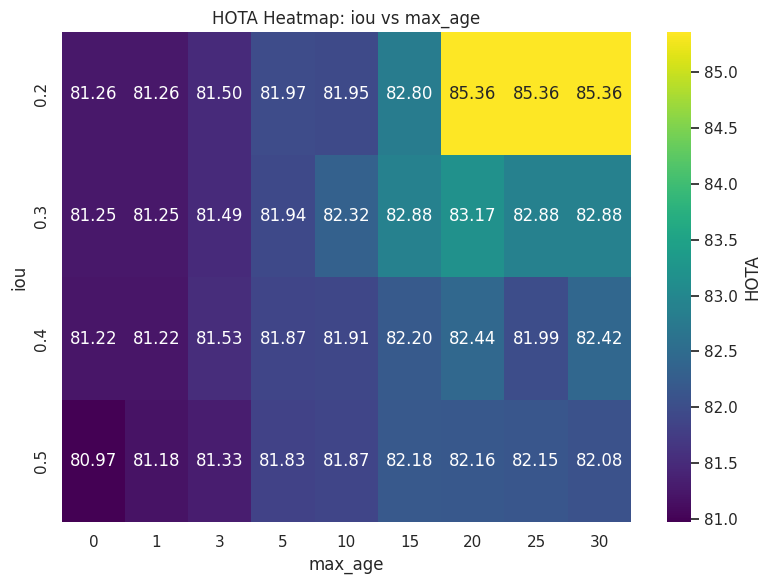

In [9]:

# Choose metric to visualize
metric = "HOTA"   # or "IDF1"

# Create pivot table
heatmap_data = df2.pivot_table(
    values=metric,
    index="iou",
    columns="max_age",
    aggfunc="max"
)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": metric},
)

plt.title(f"{metric} Heatmap: iou vs max_age")
plt.xlabel("max_age")
plt.ylabel("iou")

plt.tight_layout()
plt.show()

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def pareto_mask_max2(df: pd.DataFrame, m1: str, m2: str) -> np.ndarray:
    """
    Returns boolean mask of Pareto-optimal points for maximizing m1 and m2.
    A point is Pareto-optimal if no other point is >= in both metrics and > in at least one.
    """
    vals = df[[m1, m2]].to_numpy()
    n = vals.shape[0]
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        # Any point that dominates i?
        dominates_i = (vals[:, 0] >= vals[i, 0]) & (vals[:, 1] >= vals[i, 1]) & (
            (vals[:, 0] > vals[i, 0]) | (vals[:, 1] > vals[i, 1])
        )
        if np.any(dominates_i):
            is_pareto[i] = False
    return is_pareto


def pick_single_best_from_pareto(df: pd.DataFrame, m1: str, m2: str) -> pd.Series:
    """
    From Pareto set, pick one point to mark (red star).
    Here: maximize (m1 + m2). You can change this rule.
    """
    mask = pareto_mask_max2(df, m1, m2)
    pareto = df.loc[mask].copy()
    if pareto.empty:
        # fallback: best by sum
        return df.loc[(df[m1] + df[m2]).idxmax()]
    return pareto.loc[(pareto[m1] + pareto[m2]).idxmax()]


def errorbar_by_param(ax, df, param: str, metric: str, label: str, marker: str = "o"):
    g = df.groupby(param)[metric].agg(["mean", "std"]).reset_index().sort_values(param)
    ax.errorbar(g[param], g["mean"], yerr=g["std"], fmt=f"-{marker}", capsize=3, label=label)
    ax.set_xlabel(param.replace("_", " ").upper())
    ax.set_ylabel(f"{metric} (mean ± std)")
    ax.grid(True, alpha=0.25)


def plot_param_effects(df):
    y_min = min(df["HOTA"].min(), df["IDF1"].min())
    y_max = max(df["HOTA"].max(), df["IDF1"].max())
    
    y_min -= 0.01
    y_max += 5

    # Ensure numeric
    for c in ["iou", "max_age", "conf_threshold", "filter_thr", "min_hits", "HOTA", "IDF1"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Pick the single config to star (Pareto-based)
    best = pick_single_best_from_pareto(df, "HOTA", "IDF1")

    fig, axes = plt.subplots(5, 2, figsize=(10, 16))

    for ax in axes.flatten():
        ax.set_ylim(y_min, y_max)

    # 1) Effect of IOU on HOTA
    ax = axes[0, 0]
    errorbar_by_param(ax, df, param="iou", metric="HOTA", label="HOTA (all trials)")
    ax.scatter([best["iou"]], [best["HOTA"]], marker="*", s=180, label="Pareto Optimal")
    ax.set_title("Effect of IOU Threshold on HOTA")
    ax.legend()

    # 2) Effect of IOU on IDF1
    ax = axes[0, 1]
    errorbar_by_param(ax, df, param="iou", metric="IDF1", label="IDF1 (all trials)")
    ax.scatter([best["iou"]], [best["IDF1"]], marker="*", s=180, label="Pareto Optimal")
    ax.set_title("Effect of IOU Threshold on IDF1")
    ax.legend()

    # 3) Effect of max_age on HOTA
    ax = axes[1, 0]
    errorbar_by_param(ax, df, param="max_age", metric="HOTA", label="HOTA (all trials)")
    ax.scatter([best["max_age"]], [best["HOTA"]], marker="*", s=180, label="Pareto Optimal")
    ax.set_title("Effect of Max Age on HOTA")
    ax.legend()

    # 4) Effect of max_age on IDF1
    ax = axes[1, 1]
    errorbar_by_param(ax, df, param="max_age", metric="IDF1", label="IDF1 (all trials)")
    ax.scatter([best["max_age"]], [best["IDF1"]], marker="*", s=180, label="Pareto Optimal")
    ax.set_title("Effect of Max Age on IDF1")
    ax.legend()

    # 5) Effect of filter_thr on HOTA
    ax = axes[2, 0]
    errorbar_by_param(ax, df, param="filter_thr", metric="HOTA", label="HOTA (all trials)")
    ax.scatter([best["filter_thr"]], [best["HOTA"]], marker="*", s=180, label="Pareto Optimal")
    ax.set_title("Effect of Filter Threshold on HOTA")
    ax.legend()

    # 6) Effect of filter_thr on IDF1
    ax = axes[2, 1]
    errorbar_by_param(ax, df, param="filter_thr", metric="IDF1", label="IDF1 (all trials)")
    ax.scatter([best["filter_thr"]], [best["IDF1"]], marker="*", s=180, label="Pareto Optimal")
    ax.set_title("Effect of Filter Threshold on IDF1")
    ax.legend()

    # 7) Effect of min_hits on HOTA
    ax = axes[3, 0]
    errorbar_by_param(ax, df, param="min_hits", metric="HOTA", label="HOTA (all trials)")
    ax.scatter([best["min_hits"]], [best["HOTA"]], marker="*", s=180, label="Pareto Optimal")
    ax.set_title("Effect of Min Hits on HOTA")
    ax.legend()

    # 8) Effect of min_hits on IDF1
    ax = axes[3, 1]
    errorbar_by_param(ax, df, param="min_hits", metric="IDF1", label="IDF1 (all trials)")
    ax.scatter([best["min_hits"]], [best["IDF1"]], marker="*", s=180, label="Pareto Optimal")
    ax.set_title("Effect of Min Hits on IDF1")
    ax.legend()

    # 8) Effect of conf_threshold on HOTA
    ax = axes[4, 0]
    errorbar_by_param(ax, df, param="conf_threshold", metric="HOTA", label="HOTA (all trials)")
    ax.scatter([best["conf_threshold"]], [best["HOTA"]], marker="*", s=180, label="Pareto Optimal")
    ax.set_title("Effect of Confidence Threshold on HOTA")
    ax.legend()

    # 8) Effect of conf_threshold on IDF1
    ax = axes[4, 1]
    errorbar_by_param(ax, df, param="conf_threshold", metric="IDF1", label="IDF1 (all trials)")
    ax.scatter([best["conf_threshold"]], [best["IDF1"]], marker="*", s=180, label="Pareto Optimal")
    ax.set_title("Effect of Confidence Threshold on IDF1")
    ax.legend()

    plt.tight_layout()
    plt.show()

In [33]:
df.head()

,iou,max_age,conf_threshold,filter_thr,min_hits,HOTA,IDF1
0,0.2,0,0.3,0.3,0,65.074,61.450
1,0.2,0,0.3,0.3,1,65.040,61.553
2,0.2,0,0.3,0.3,3,64.746,61.392
3,0.2,0,0.3,0.3,5,64.410,61.144
4,0.2,0,0.3,0.3,10,63.651,60.420


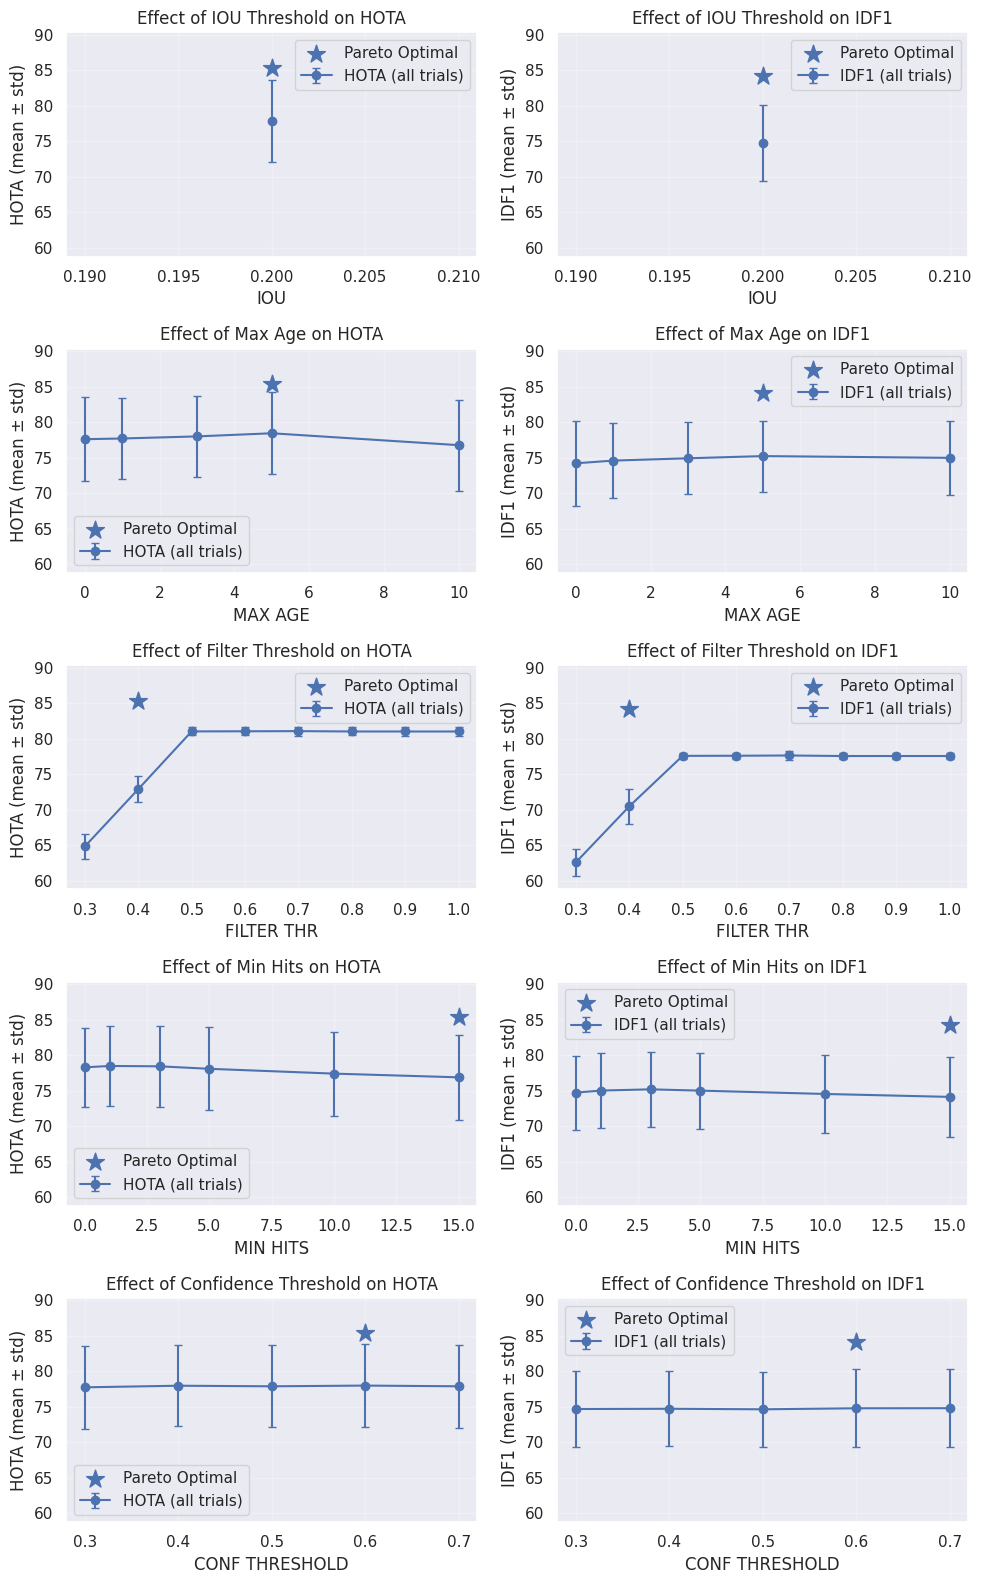

In [34]:
plot_param_effects(df)

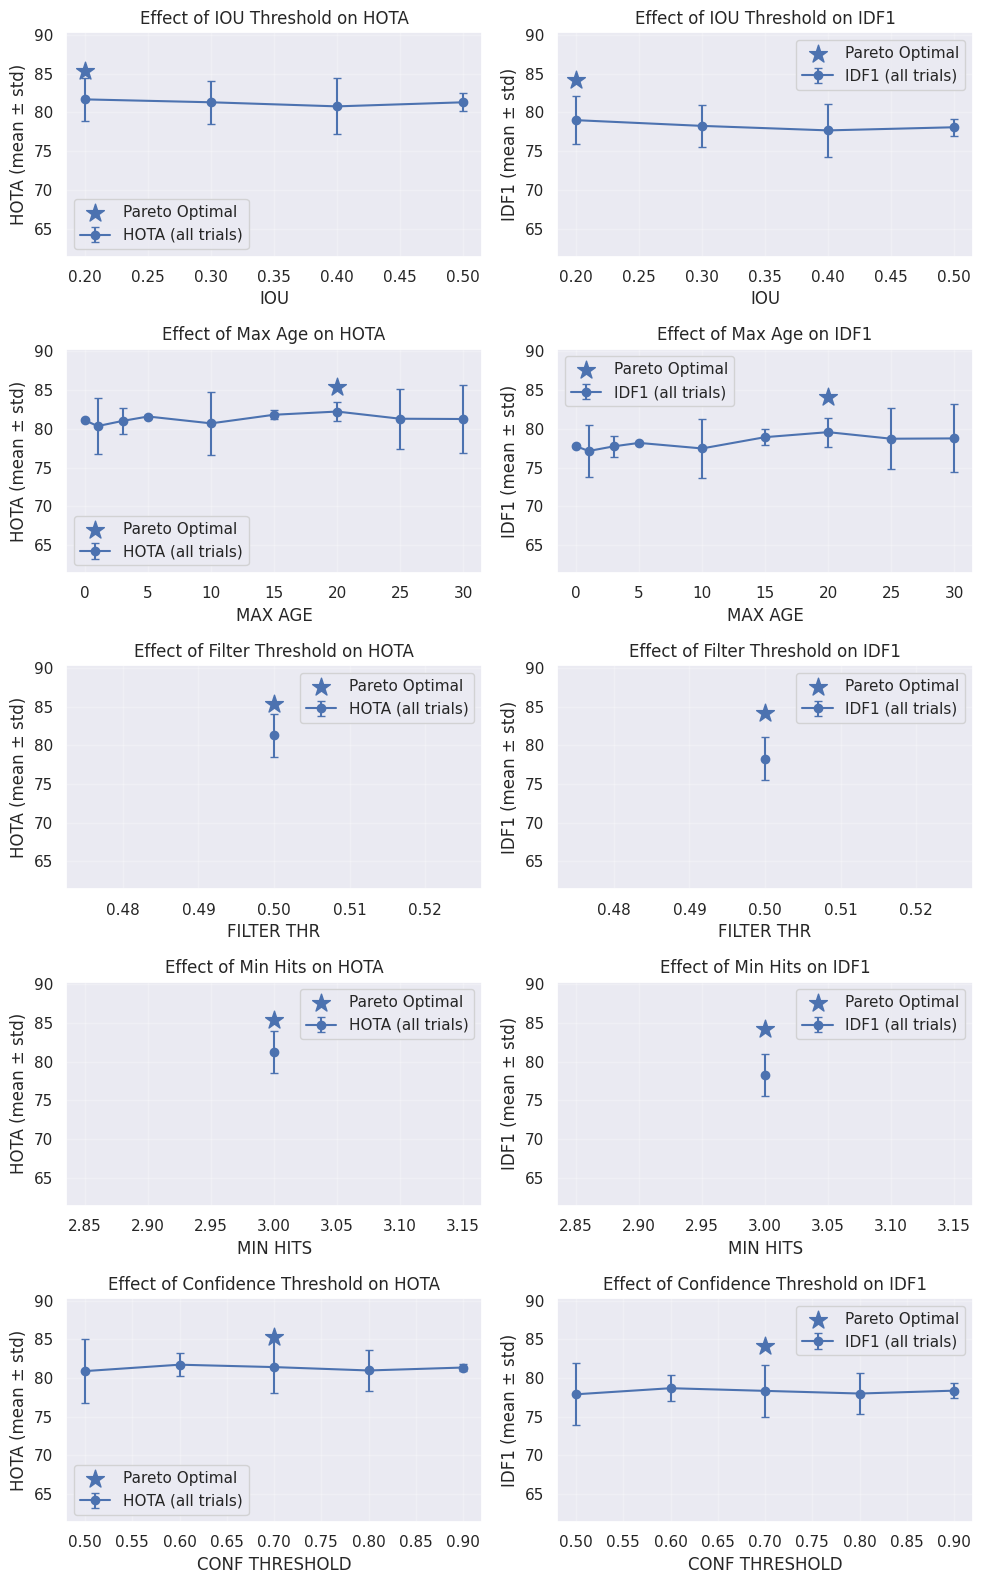

In [35]:
plot_param_effects(df2)

In [36]:
print(df["HOTA"].max())
print(df["IDF1"].max())

85.357
84.18


In [37]:
print(df2["HOTA"].max())
print(df2["IDF1"].max())

85.357
84.18


In [38]:
df[df["HOTA"] == df["HOTA"].max()][["HOTA", "IDF1", "iou", "max_age", "conf_threshold", "filter_thr", "min_hits"]]

,HOTA,IDF1,iou,max_age,conf_threshold,filter_thr,min_hits
875,85.357,84.18,0.2,5,0.6,0.4,15


In [39]:
df[df["IDF1"] == df["IDF1"].max()][["HOTA", "IDF1", "iou", "max_age", "conf_threshold", "filter_thr", "min_hits"]]

,HOTA,IDF1,iou,max_age,conf_threshold,filter_thr,min_hits
875,85.357,84.18,0.2,5,0.6,0.4,15


In [40]:
df2[df2["IDF1"] == df2["IDF1"].max()][["HOTA", "IDF1", "iou", "max_age", "conf_threshold", "filter_thr", "min_hits"]]

,HOTA,IDF1,iou,max_age,conf_threshold,filter_thr,min_hits
122,85.357,84.18,0.2,20,0.7,0.5,3
127,85.357,84.18,0.2,25,0.7,0.5,3
132,85.356,84.18,0.2,30,0.7,0.5,3


In [41]:
df3 = pd.concat([df, df2], ignore_index=True)

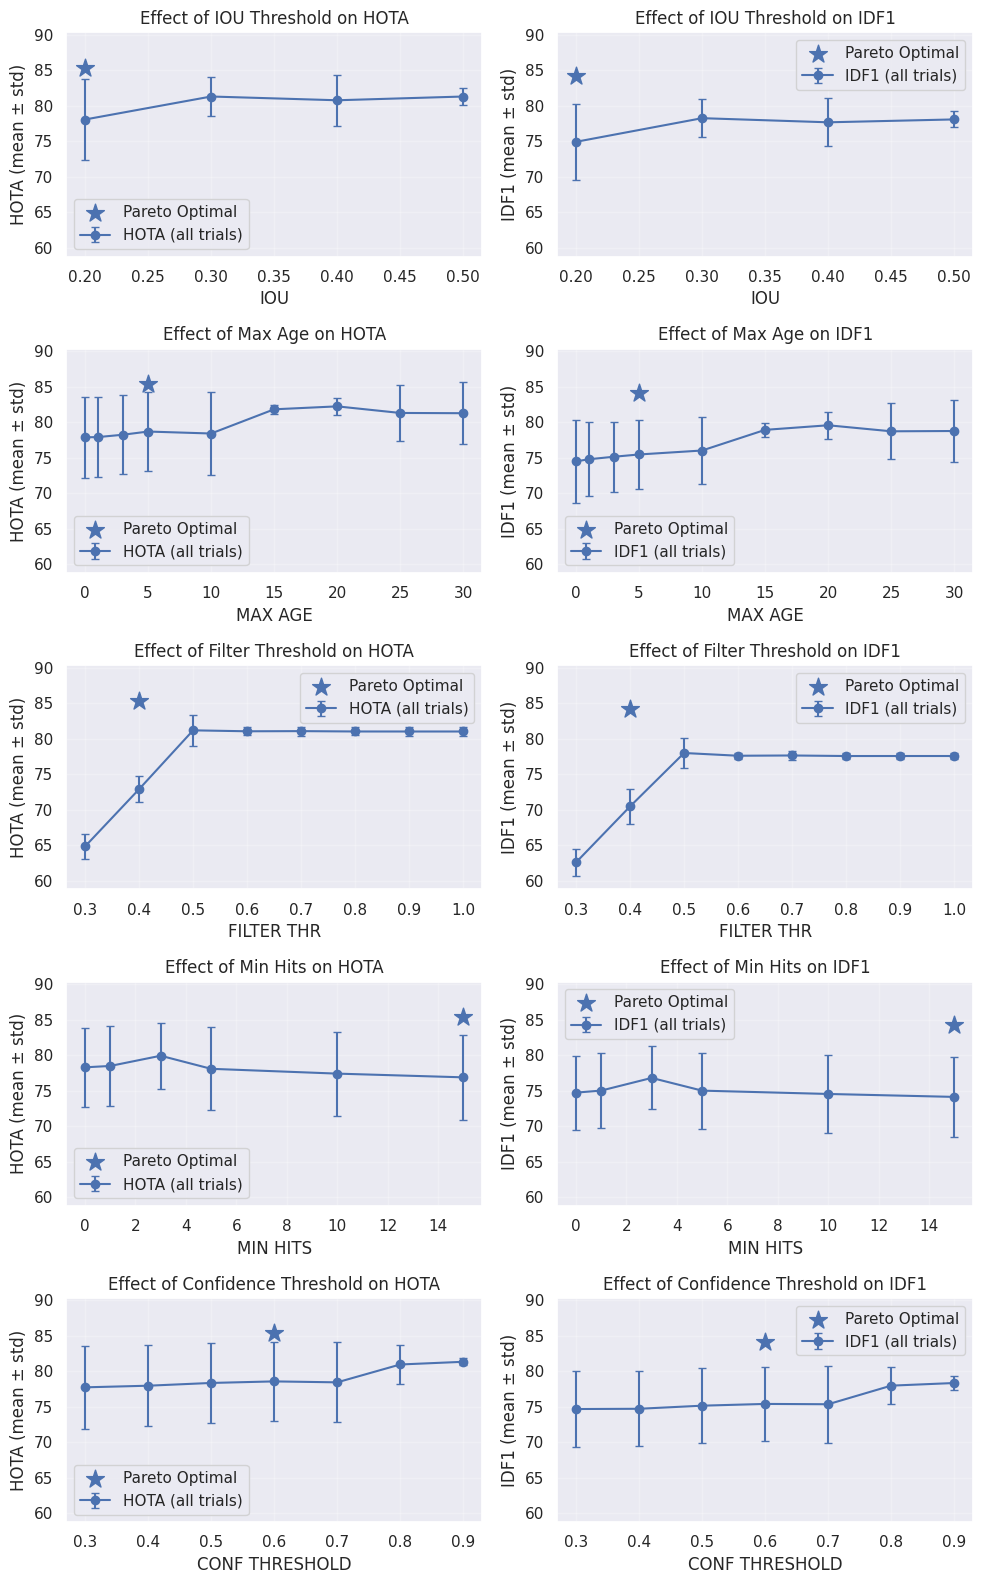

In [42]:
plot_param_effects(df3)

In [60]:
def errorbar_by_param(ax, df, param, metric, label, color):
    g = df.groupby(param)[metric].agg(["mean", "std"]).reset_index().sort_values(param)

    ax.errorbar(
        g[param],
        g["mean"],
        yerr=g["std"],
        fmt="o-",
        color=color,
        capsize=3,
        label=label
    )

    ax.set_xlabel(param.replace("_", " ").upper())
    ax.set_ylabel(f"{metric} (mean ± std)")
    ax.grid(True, alpha=0.25)

In [63]:
def plot_param_effects(df):

    y_min = min(df["HOTA"].min(), df["IDF1"].min())
    y_max = max(df["HOTA"].max(), df["IDF1"].max())

    y_min -= 0.01
    y_max += 5

    # Ensure numeric
    for c in ["iou", "max_age", "conf_threshold", "filter_thr", "min_hits", "HOTA", "IDF1"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Manually chosen best configuration
    best = {
        "iou": 0.2,
        "conf_threshold": 0.7,
        "filter_thr": 0.5,
        "max_age": 20,
        "min_hits": 3,
        "HOTA": 85.36,
        "IDF1": 84.18
    }

    fig, axes = plt.subplots(2, 5, figsize=(24, 7))

    for ax in axes.flatten():
        ax.set_ylim(y_min, y_max)

    # Helper function to avoid repetition
    def add_best(ax, x, y):
        ax.scatter([x], [y], marker="*", s=180, label="Best value")

    param_colors = {
        "iou": "#4C72B0",          # blue
        "conf_threshold": "#55A868", # green
        "filter_thr": "#C44E52",   # red
        "max_age": "#DD8452",      # orange
        "min_hits": "#8172B3"      # purple
    }

    # IOU
    ax = axes[0, 0]
    errorbar_by_param(ax, df, "iou", "HOTA", "HOTA (all trials)", color=param_colors["iou"])
    add_best(ax, best["iou"], best["HOTA"])
    ax.set_title("Effect of IOU Threshold on HOTA")
    ax.legend()

    ax = axes[1, 0]
    errorbar_by_param(ax, df, "iou", "IDF1", "IDF1 (all trials)", color=param_colors["iou"])
    add_best(ax, best["iou"], best["IDF1"])
    ax.set_title("Effect of IOU Threshold on IDF1")
    ax.legend()

    # Confidence threshold
    ax = axes[0, 1]
    errorbar_by_param(ax, df, "conf_threshold", "HOTA", "HOTA (all trials)", color=param_colors["conf_threshold"])
    add_best(ax, best["conf_threshold"], best["HOTA"])
    ax.set_title("Effect of Confidence Threshold on HOTA")
    ax.legend()

    ax = axes[1, 1]
    errorbar_by_param(ax, df, "conf_threshold", "IDF1", "IDF1 (all trials)", color=param_colors["conf_threshold"])
    add_best(ax, best["conf_threshold"], best["IDF1"])
    ax.set_title("Effect of Confidence Threshold on IDF1")
    ax.legend()

    # Filter threshold
    ax = axes[0, 2]
    errorbar_by_param(ax, df, "filter_thr", "HOTA", "HOTA (all trials)", color=param_colors["filter_thr"])
    add_best(ax, best["filter_thr"], best["HOTA"])
    ax.set_title("Effect of Filter Threshold on HOTA")
    ax.legend()

    ax = axes[1, 2]
    errorbar_by_param(ax, df, "filter_thr", "IDF1", "IDF1 (all trials)", color=param_colors["filter_thr"])
    add_best(ax, best["filter_thr"], best["IDF1"])
    ax.set_title("Effect of Filter Threshold on IDF1")
    ax.legend()

    # Max age
    ax = axes[0, 3]
    errorbar_by_param(ax, df, "max_age", "HOTA", "HOTA (all trials)", color=param_colors["max_age"])
    add_best(ax, best["max_age"], best["HOTA"])
    ax.set_title("Effect of Max Age on HOTA")
    ax.legend()

    ax = axes[1, 3]
    errorbar_by_param(ax, df, "max_age", "IDF1", "IDF1 (all trials)", color=param_colors["max_age"])
    add_best(ax, best["max_age"], best["IDF1"])
    ax.set_title("Effect of Max Age on IDF1")
    ax.legend()

    # Min hits
    ax = axes[0, 4]
    errorbar_by_param(ax, df, "min_hits", "HOTA", "HOTA (all trials)", color=param_colors["min_hits"])
    add_best(ax, best["min_hits"], best["HOTA"])
    ax.set_title("Effect of Min Hits on HOTA")
    ax.legend()

    ax = axes[1, 4]
    errorbar_by_param(ax, df, "min_hits", "IDF1", "IDF1 (all trials)", color=param_colors["min_hits"])
    add_best(ax, best["min_hits"], best["IDF1"])
    ax.set_title("Effect of Min Hits on IDF1")
    ax.legend()

    plt.tight_layout()
    plt.show()

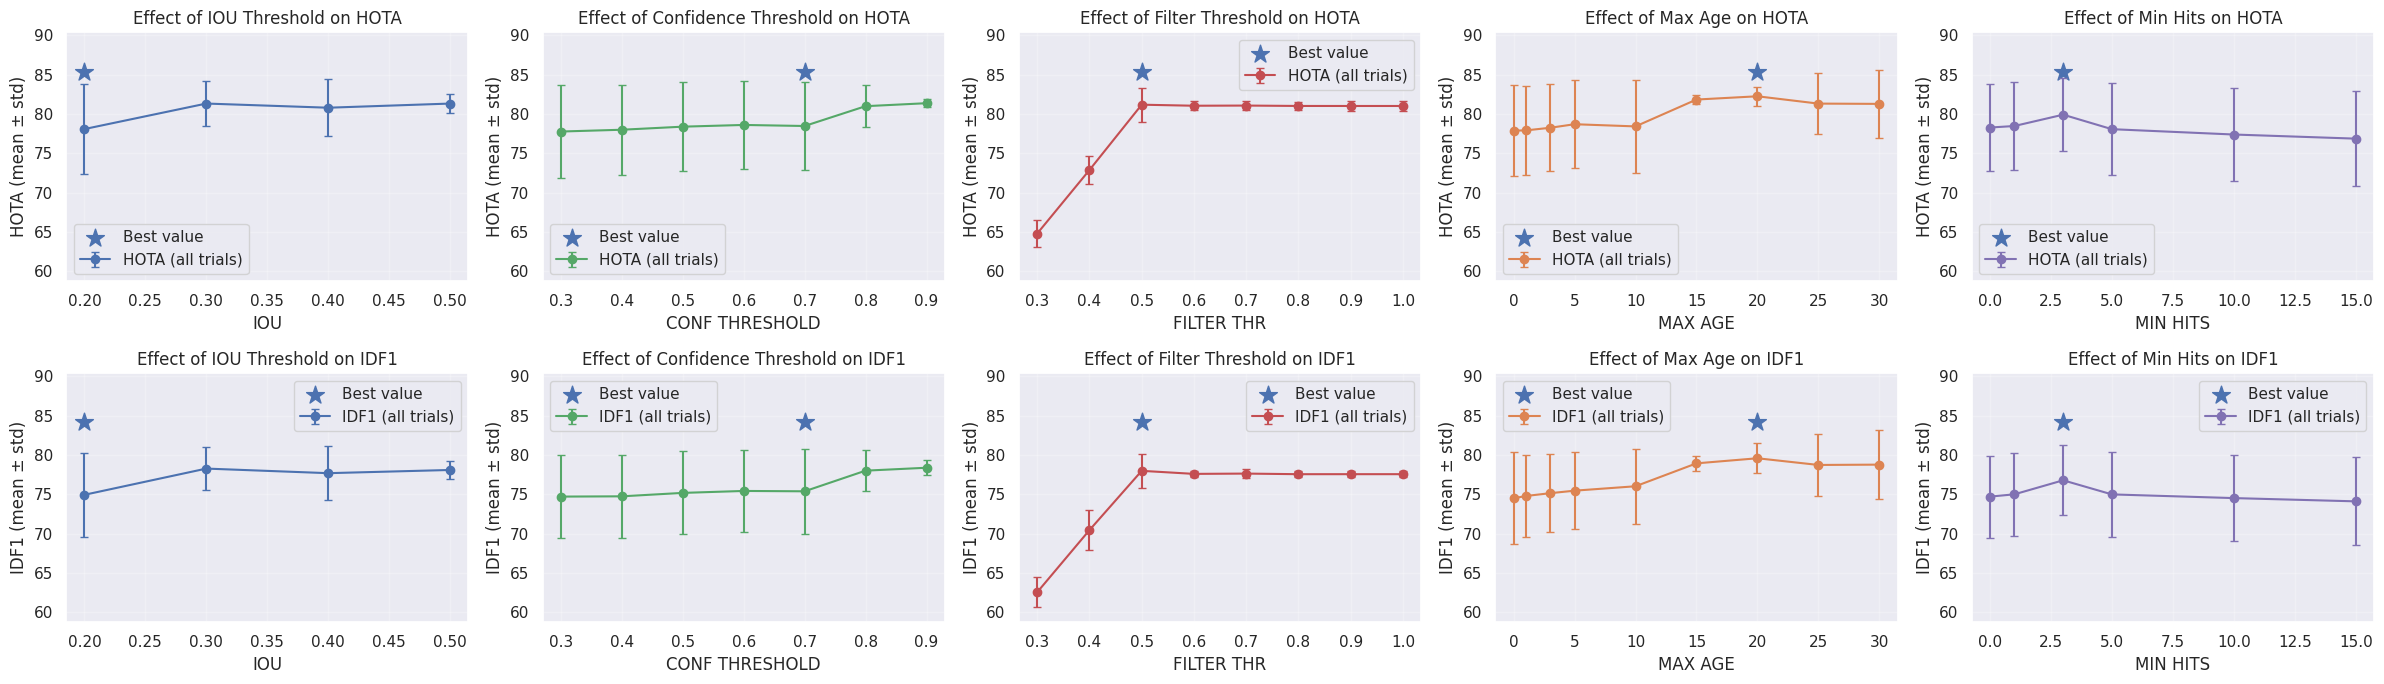

In [64]:
plot_param_effects(df3)